In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
from pathlib import Path

def analyze_cohort_results(data_dir='.', user_type='large', months_list=[1,2,3], 
                           significance_threshold=0.05):
    """
    Analyze result CSV files for a given user type and cohort window lengths.
    
    Parameters:
    data_dir : directory containing CSV files
    user_type : 'large', 'retail', or 'risky'
    months_list : list of month lengths to include (e.g., [1,2,3])
    significance_threshold : p-value threshold for significance
    
    Returns:
    summary_df : DataFrame with aggregated statistics
    """
    # Find all CSV files in the directory
    files = glob.glob(str(Path(data_dir) / '*.csv'))
    
    # Filter files that match pattern: base_cbbtc_usdc_{window}month_{user_type}.csv
    pattern = re.compile(rf'base_cbbtc_usdc_(\d+)month_{user_type}\.csv')
    
    dataframes = []
    for f in files:
        m = pattern.search(f)
        if m:
            months = int(m.group(1))
            if months in months_list:
                df = pd.read_csv(f)
                df['window_months'] = months
                dataframes.append(df)
    
    if not dataframes:
        print(f"No files found for user_type='{user_type}' with months {months_list}")
        return None
    
    combined = pd.concat(dataframes, ignore_index=True).fillna(0)#.drop(columns=["p_collateral_price_vs_open", "coef_collateral_price_vs_open", 'p_log_debt', 'coef_log_debt'], )
    # combined = pd.concat(dataframes, ignore_index=True).fillna(0).drop(columns=["p_collateral_price_vs_open", "coef_collateral_price_vs_open", 'p_log_debt', 'coef_log_debt'], )
    
    # Identify feature columns (p-values and coefficients)
    p_cols = [col for col in combined.columns if col.startswith('p_') and col != 'p_mean']
    coef_cols = [col for col in combined.columns if col.startswith('coef_') and col != 'coef_const']
    elastic_cols = [col for col in combined.columns if col.startswith('elasticity_')]
    
    # Extract feature names (remove prefix)
    features = [col[2:] for col in p_cols]  # strip 'p_'
    
    # Build summary DataFrame
    summary = []
    for feat in features:
        p_vals = combined[f'p_{feat}']
        coef_vals = combined[f'coef_{feat}']
        elastic_vals = combined[f'elasticity_{feat}'] if f'elasticity_{feat}' in combined else np.nan
        
        sig_frac = (p_vals < significance_threshold).mean()
        avg_coef = coef_vals.mean()
        avg_elastic = elastic_vals.mean() if not np.isnan(elastic_vals).all() else np.nan
        pos_frac = (coef_vals > 0).mean()
        
        summary.append({
            'feature': feat,
            'significance_fraction': sig_frac,
            'avg_coefficient': avg_coef,
            'coef_positive_fraction': pos_frac,
            'avg_elasticity': avg_elastic,
            'n_intervals': len(combined)
        })
    
    summary_df = pd.DataFrame(summary).sort_values('significance_fraction', ascending=False)
    
    # Print report
    print(f"\n{'='*60}")
    print(f"ANALYSIS REPORT - User Type: {user_type.upper()} (months {months_list})")
    print(f"{'='*60}")
    print(f"Total intervals analyzed: {len(combined)}")
    print(f"\n--- Feature Significance (p < {significance_threshold}) ---")
    print(summary_df[['feature', 'significance_fraction', 'avg_coefficient', 'coef_positive_fraction']].head(15).to_string(index=False))
    
    print("\n--- Average Elasticity (where available) ---")
    elastic_df = summary_df.dropna(subset=['avg_elasticity']).sort_values('avg_elasticity', ascending=False)
    print(elastic_df[['feature', 'avg_elasticity']].head(10).to_string(index=False))
    
    # Plotting
    # 1. Significance bar chart
    plt.figure(figsize=(12, 6))
    top_significant = summary_df.head(15)
    plt.barh(top_significant['feature'], top_significant['significance_fraction'], color='steelblue')
    plt.xlabel('Fraction of intervals significant')
    plt.title(f'Feature Significance - {user_type.upper()}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # 2. Coefficient distribution boxplots for top features
    top_features = summary_df.head(10)['feature'].tolist()
    if len(top_features) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(15, 8))
        axes = axes.flatten()
        for ax, feat in zip(axes, top_features):
            data = combined[f'coef_{feat}'].dropna()
            ax.boxplot(data, vert=False)
            ax.set_title(feat, fontsize=10)
            ax.set_xlabel('Coefficient')
        plt.tight_layout()
        plt.show()
    
    # 3. Elasticity distribution (if available)
    elastic_features = [f for f in features if f'elasticity_{f}' in combined.columns]
    if elastic_features:
        elastic_data = combined[[f'elasticity_{f}' for f in elastic_features[:5]]].melt(var_name='feature', value_name='elasticity')
        elastic_data['feature'] = elastic_data['feature'].str.replace('elasticity_', '')
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='feature', y='elasticity', data=elastic_data)
        plt.title(f'Elasticity Distribution - {user_type.upper()}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    return summary_df



ANALYSIS REPORT - User Type: RISKY (months [1, 2, 3])
Total intervals analyzed: 30

--- Feature Significance (p < 0.05) ---
               feature  significance_fraction  avg_coefficient  coef_positive_fraction
           ltv_vs_open               1.000000         0.547595                0.966667
     borrow_rate_trend               0.866667         0.255312                0.666667
           hour_of_day               0.800000         0.026388                0.300000
        ltv_times_rate               0.766667        -1.189426                0.333333
       distance_to_liq               0.733333        -0.768717                0.400000
           day_of_week               0.700000         0.006611                0.233333
   borrow_rate_vs_open               0.666667        -0.169958                0.400000
collateral_price_vs_6h               0.633333        -0.141612                0.200000
         ltv_change_1h               0.633333        -0.106229                0.300000
     

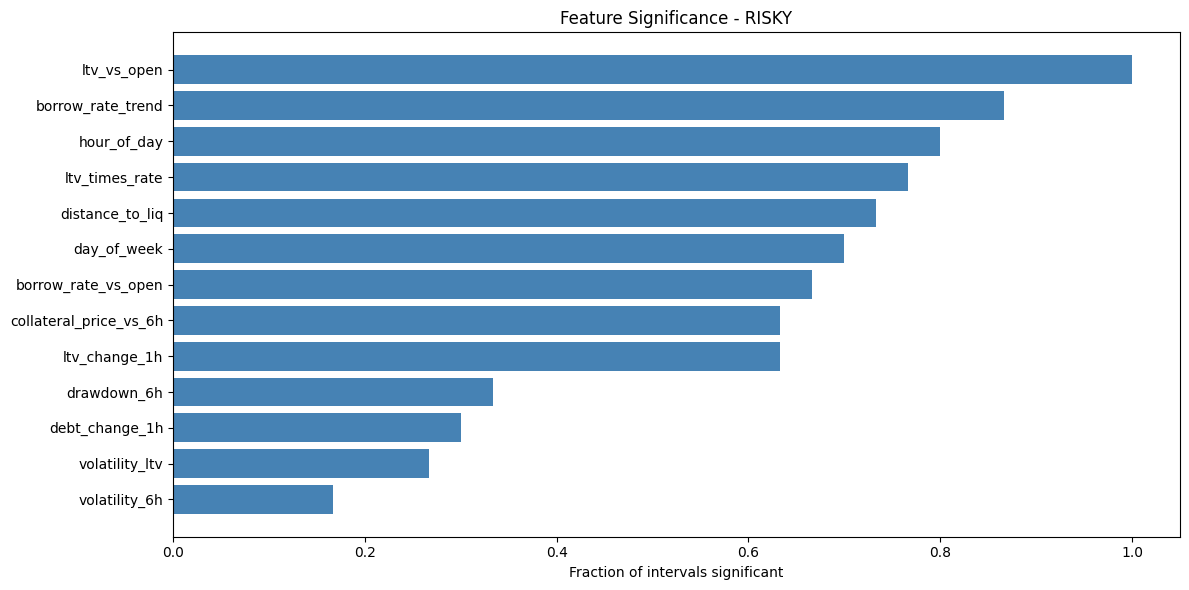

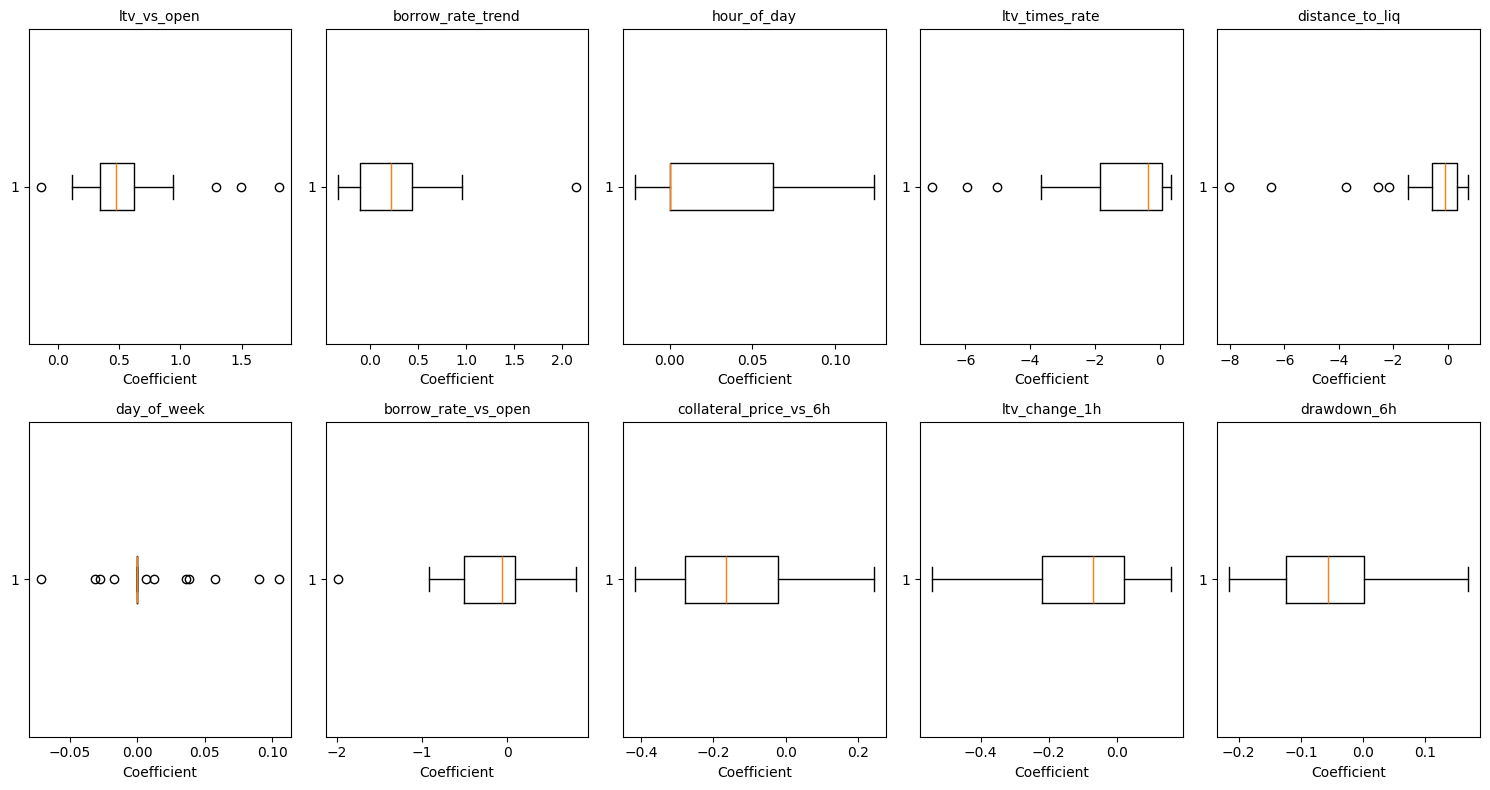

,feature,significance_fraction,avg_coefficient,coef_positive_fraction,avg_elasticity,n_intervals
1,ltv_vs_open,1.000000,0.547595,0.966667,NaN,30
7,borrow_rate_trend,0.866667,0.255312,0.666667,NaN,30
11,hour_of_day,0.800000,0.026388,0.300000,NaN,30
8,ltv_times_rate,0.766667,-1.189426,0.333333,NaN,30
6,distance_to_liq,0.733333,-0.768717,0.400000,NaN,30
12,day_of_week,0.700000,0.006611,0.233333,NaN,30
0,borrow_rate_vs_open,0.666667,-0.169958,0.400000,NaN,30
2,collateral_price_vs_6h,0.633333,-0.141612,0.200000,NaN,30
5,ltv_change_1h,0.633333,-0.106229,0.300000,NaN,30
4,drawdown_6h,0.333333,-0.059694,0.266667,NaN,30


In [5]:
summary = analyze_cohort_results(data_dir='/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/cohort_elasticity_smart', user_type="risky", months_list=[1,2,3])
summary


ANALYSIS REPORT - User Type: RISKY (months [1, 2, 3])
Total intervals analyzed: 30

--- Feature Significance (p < 0.05) ---
               feature  significance_fraction  avg_coefficient  coef_positive_fraction
        ltv_times_rate               0.700000        -2.483614                0.333333
           ltv_vs_open               0.600000         2.076010                0.866667
         ltv_change_1h               0.500000         0.158861                0.733333
       log_dist_to_liq               0.500000        -1.780915                0.200000
       distance_to_liq               0.433333         1.689508                0.566667
     borrow_rate_trend               0.400000         0.241570                0.633333
           day_of_week               0.400000        -0.032967                0.433333
   borrow_rate_vs_open               0.366667        -0.537916                0.400000
           hour_of_day               0.366667         0.071227                0.700000
colla

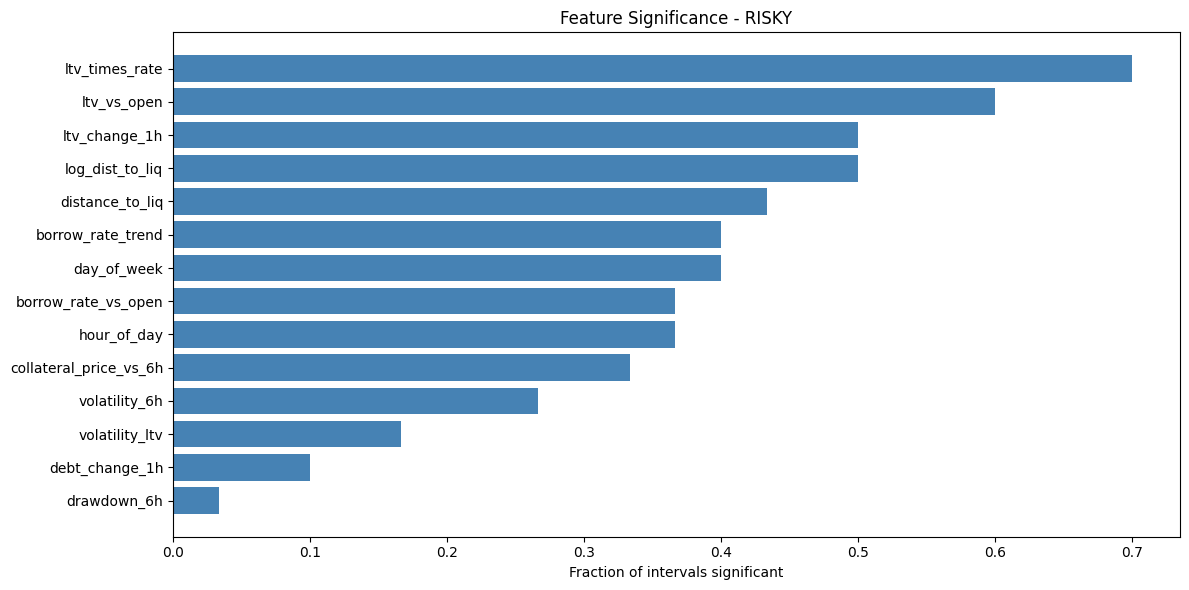

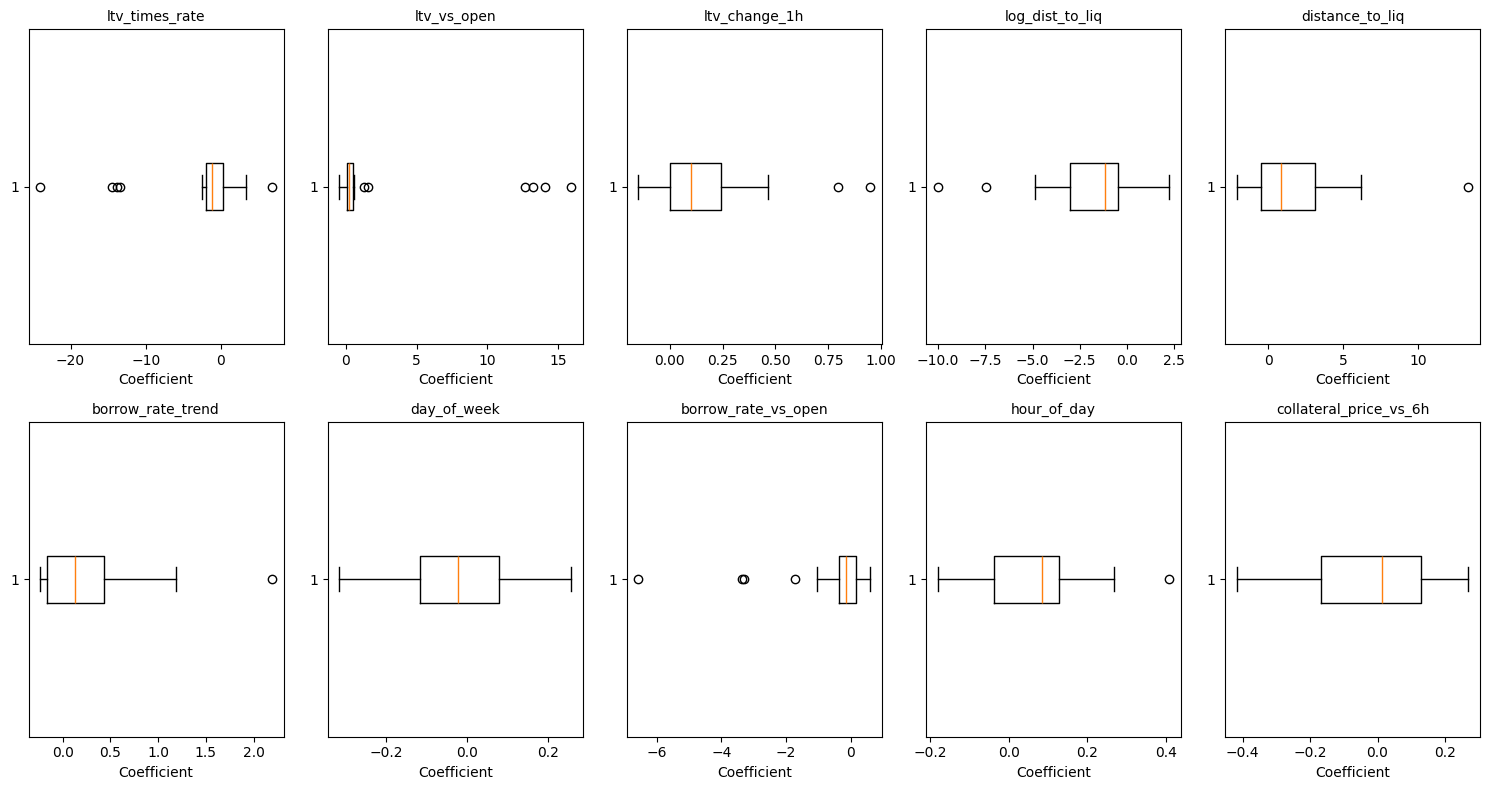

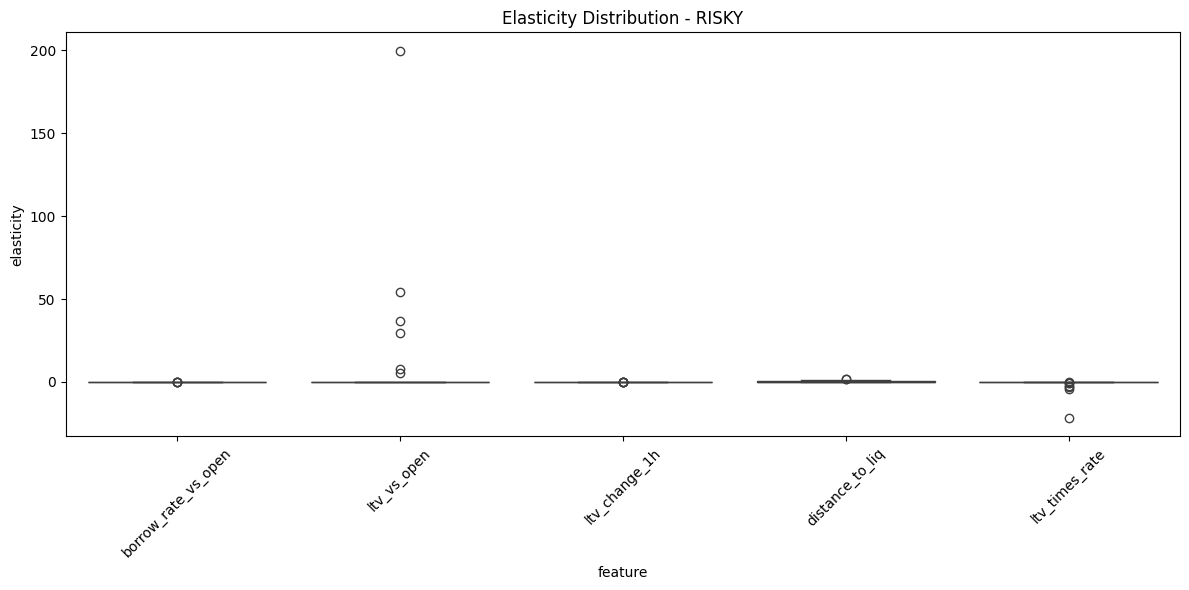

,feature,significance_fraction,avg_coefficient,coef_positive_fraction,avg_elasticity,n_intervals
8,ltv_times_rate,0.700000,-2.483614,0.333333,-1.122359,30
1,ltv_vs_open,0.600000,2.076010,0.866667,11.123292,30
5,ltv_change_1h,0.500000,0.158861,0.733333,-0.000889,30
11,log_dist_to_liq,0.500000,-1.780915,0.200000,NaN,30
6,distance_to_liq,0.433333,1.689508,0.566667,0.269393,30
7,borrow_rate_trend,0.400000,0.241570,0.633333,NaN,30
13,day_of_week,0.400000,-0.032967,0.433333,NaN,30
0,borrow_rate_vs_open,0.366667,-0.537916,0.400000,-0.003100,30
12,hour_of_day,0.366667,0.071227,0.700000,NaN,30
2,collateral_price_vs_6h,0.333333,-0.022309,0.500000,NaN,30


In [18]:
summary = analyze_cohort_results(data_dir='/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/cohort_elasticity', user_type="risky", months_list=[1,2,3])
summary


ANALYSIS REPORT - User Type: LARGE (months [1, 2, 3])
Total intervals analyzed: 30

--- Feature Significance (p < 0.05) ---
               feature  significance_fraction  avg_coefficient  coef_positive_fraction
       log_dist_to_liq               0.966667        -2.552505                0.000000
           ltv_vs_open               0.933333         2.317475                0.966667
       distance_to_liq               0.933333         1.821126                0.833333
           hour_of_day               0.800000         0.122561                0.966667
   borrow_rate_vs_open               0.700000        -0.785637                0.166667
         ltv_change_1h               0.600000        -0.337378                0.366667
     borrow_rate_trend               0.600000         0.758510                0.900000
collateral_price_vs_6h               0.566667        -0.030966                0.400000
        ltv_times_rate               0.500000        -2.544579                0.100000
     

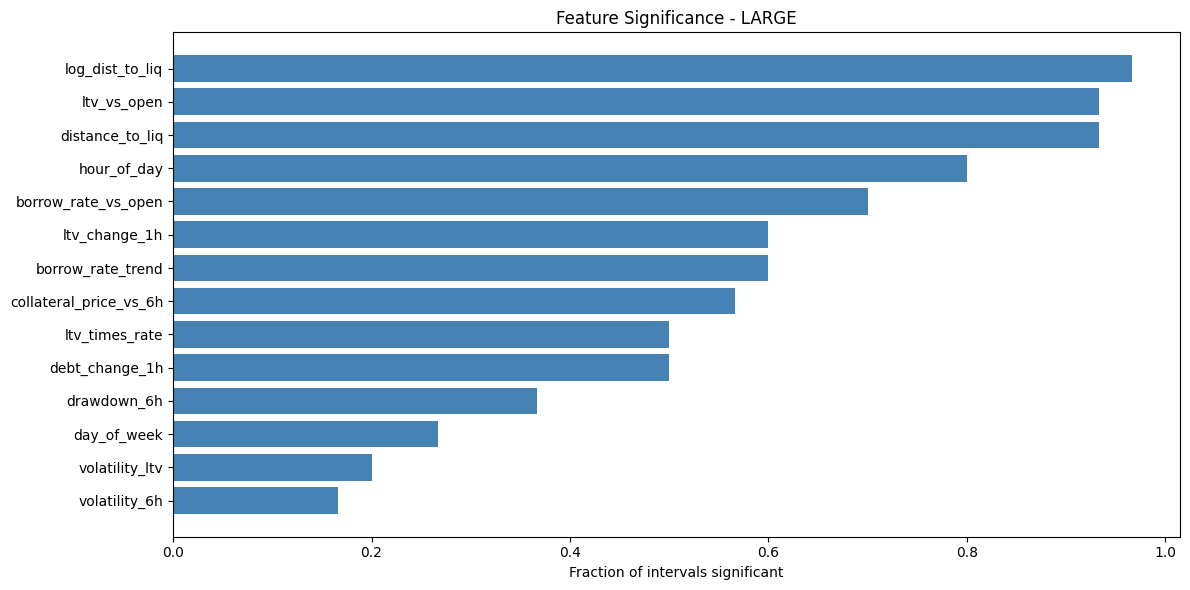

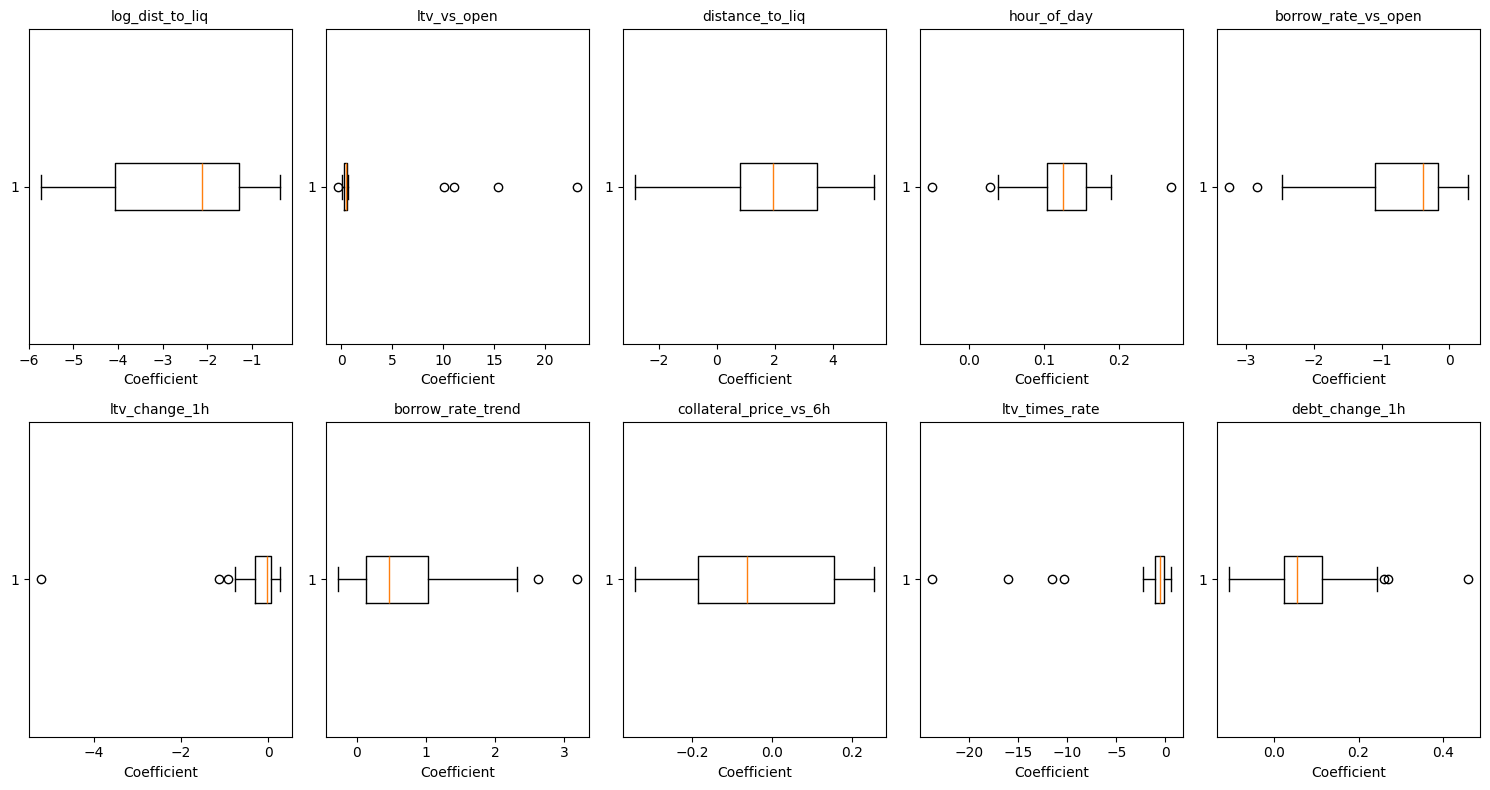

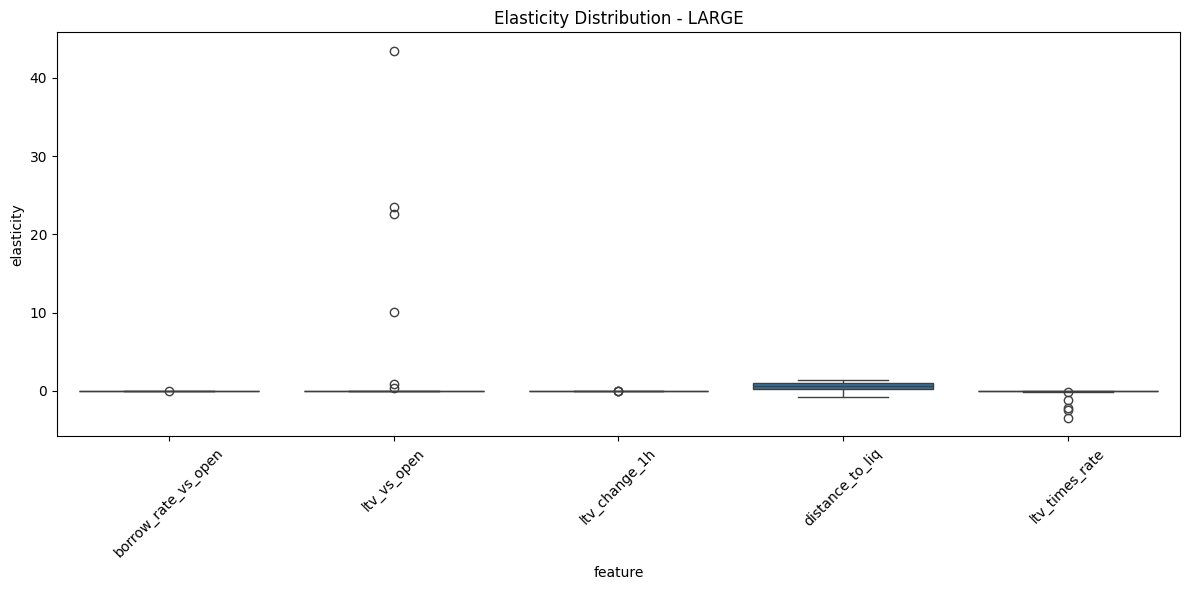

,feature,significance_fraction,avg_coefficient,coef_positive_fraction,avg_elasticity,n_intervals
11,log_dist_to_liq,0.966667,-2.552505,0.000000,NaN,30
1,ltv_vs_open,0.933333,2.317475,0.966667,3.365529,30
6,distance_to_liq,0.933333,1.821126,0.833333,0.523591,30
12,hour_of_day,0.800000,0.122561,0.966667,NaN,30
0,borrow_rate_vs_open,0.700000,-0.785637,0.166667,-0.006102,30
5,ltv_change_1h,0.600000,-0.337378,0.366667,0.000921,30
7,borrow_rate_trend,0.600000,0.758510,0.900000,NaN,30
2,collateral_price_vs_6h,0.566667,-0.030966,0.400000,NaN,30
8,ltv_times_rate,0.500000,-2.544579,0.100000,-0.327607,30
9,debt_change_1h,0.500000,0.089406,0.966667,NaN,30


In [19]:
summary = analyze_cohort_results(data_dir='/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/cohort_elasticity', user_type="large", months_list=[1,2,3])
summary